In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/road-accident-united-kingdom-uk-dataset/UK_Accident.csv


In [ ]:
# pip install pandas matplotlib scikit-learn imbalanced-learn


In [3]:
# Step 1: Load necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import LabelEncoder

# Step 2: Load the dataset
file_path = '/kaggle/input/road-accident-united-kingdom-uk-dataset/UK_Accident.csv'  # Use the correct path for your dataset
df = pd.read_csv(file_path)


In [6]:
# Step 3: Explore the dataset
print(df.head())  # To inspect the first few rows
print(df['Accident_Severity'].value_counts())  # Check the imbalance of the target column


   Unnamed: 0 Accident_Index  Location_Easting_OSGR  Location_Northing_OSGR  \
0           0  200501BS00001               525680.0                178240.0   
1           1  200501BS00002               524170.0                181650.0   
2           2  200501BS00003               524520.0                182240.0   
3           3  200501BS00004               526900.0                177530.0   
4           4  200501BS00005               528060.0                179040.0   

   Longitude   Latitude  Police_Force  Accident_Severity  Number_of_Vehicles  \
0  -0.191170  51.489096             1                  2                   1   
1  -0.211708  51.520075             1                  3                   1   
2  -0.206458  51.525301             1                  3                   2   
3  -0.173862  51.482442             1                  3                   1   
4  -0.156618  51.495752             1                  3                   1   

   Number_of_Casualties  ...      Pedestrian

In [8]:
# Step 4: Preprocessing - Convert categorical columns to numeric (if any)
# For simplicity, we use LabelEncoder to convert string columns to numbers
label_encoder = LabelEncoder()
for column in df.select_dtypes(include=['object']).columns:
    df[column] = label_encoder.fit_transform(df[column])

In [9]:
# Step 5: Define features (X) and target (y)
X = df.drop('Accident_Severity', axis=1)  # All columns except 'Accident_Severity'
y = df['Accident_Severity']

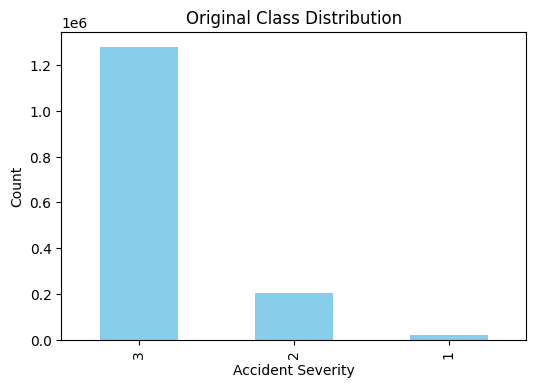

In [11]:
# Step 6: Visualize the original class distribution
plt.figure(figsize=(6, 4))
df['Accident_Severity'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Original Class Distribution')
plt.xlabel('Accident Severity')
plt.ylabel('Count')
plt.show()

   Unnamed: 0  Accident_Index  Location_Easting_OSGR  Location_Northing_OSGR  \
0           0             372               525680.0                178240.0   
1           1             373               524170.0                181650.0   
2           2             374               524520.0                182240.0   
3           3             375               526900.0                177530.0   
4           4             376               528060.0                179040.0   

   Longitude   Latitude  Police_Force  Accident_Severity  Number_of_Vehicles  \
0  -0.191170  51.489096             1                  2                   1   
1  -0.211708  51.520075             1                  3                   1   
2  -0.206458  51.525301             1                  3                   2   
3  -0.173862  51.482442             1                  3                   1   
4  -0.156618  51.495752             1                  3                   1   

   Number_of_Casualties  ...  Pedestri

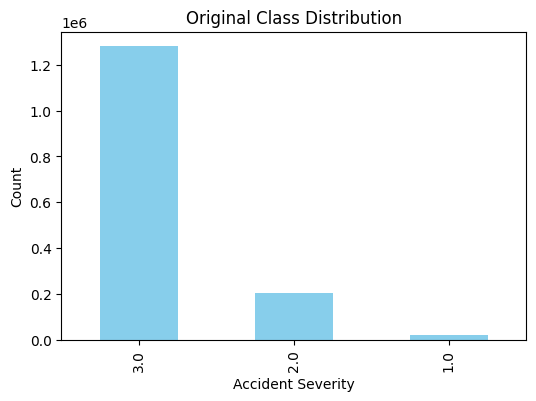

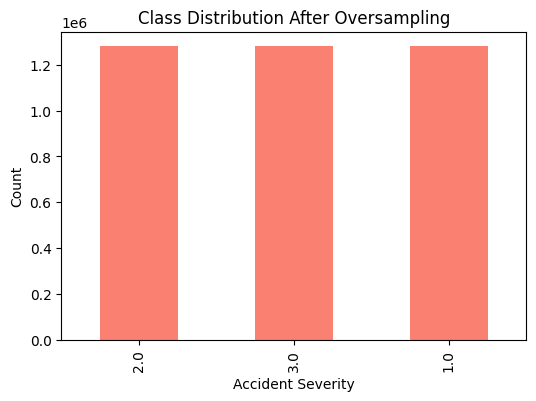

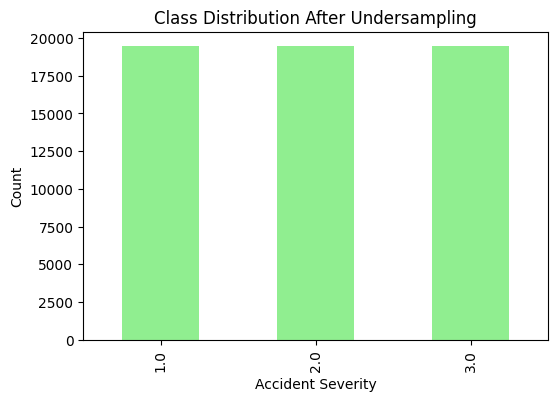

In [13]:
from sklearn.impute import SimpleImputer


# Step 3: Explore the dataset
print(df.head())  # To inspect the first few rows
print(df['Accident_Severity'].value_counts())  # Check the imbalance of the target column

# Step 4: Preprocessing - Convert categorical columns to numeric (if any)
label_encoder = LabelEncoder()
for column in df.select_dtypes(include=['object']).columns:
    df[column] = label_encoder.fit_transform(df[column])

# Step 5: Handle missing values (Imputation)
# Using SimpleImputer to replace NaN values with the median (you can change the strategy if needed)
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Step 6: Define features (X) and target (y)
X = df_imputed.drop('Accident_Severity', axis=1)  # All columns except 'Accident_Severity'
y = df_imputed['Accident_Severity']

# Step 7: Visualize the original class distribution
plt.figure(figsize=(6, 4))
y.value_counts().plot(kind='bar', color='skyblue')
plt.title('Original Class Distribution')
plt.xlabel('Accident Severity')
plt.ylabel('Count')
plt.show()

# Step 8: Handle imbalance using Oversampling (SMOTE) and Undersampling (RandomUnderSampler)

# Oversampling using SMOTE (Synthetic Minority Over-sampling Technique)
smote = SMOTE(random_state=42)
X_oversampled, y_oversampled = smote.fit_resample(X, y)

# Undersampling using RandomUnderSampler
undersample = RandomUnderSampler(random_state=42)
X_undersampled, y_undersampled = undersample.fit_resample(X, y)

# Step 9: Visualize the class distribution after oversampling and undersampling

# Visualizing oversampled class distribution
plt.figure(figsize=(6, 4))
pd.Series(y_oversampled).value_counts().plot(kind='bar', color='salmon')
plt.title('Class Distribution After Oversampling')
plt.xlabel('Accident Severity')
plt.ylabel('Count')
plt.show()

# Visualizing undersampled class distribution
plt.figure(figsize=(6, 4))
pd.Series(y_undersampled).value_counts().plot(kind='bar', color='lightgreen')
plt.title('Class Distribution After Undersampling')
plt.xlabel('Accident Severity')
plt.ylabel('Count')
plt.show()
